# Discretization


In [1]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer

In [3]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# impute missing values 
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())

In [5]:
# age discritization
age_discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
df['age_bin'] = age_discretizer.fit_transform(df[['age']])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_bin
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,2.0


c:\Users\nasik\miniconda3\envs\python_ml\Lib\site-packages\jedi\inference\compiled\subprocess\functions.py:21: UserWarning: Module numpy._core.array not importable in path ['c:\\Users\\nasik\\miniconda3\\envs\\python_ml\\python311.zip', 'c:\\Users\\nasik\\miniconda3\\envs\\python_ml\\DLLs', 'c:\\Users\\nasik\\miniconda3\\envs\\python_ml\\Lib', 'c:\\Users\\nasik\\miniconda3\\envs\\python_ml', 'c:\\Users\\nasik\\miniconda3\\envs\\python_ml\\Lib\\site-packages'].
  return access.load_module(inference_state, **kwargs)


<Axes: xlabel='age', ylabel='Count'>

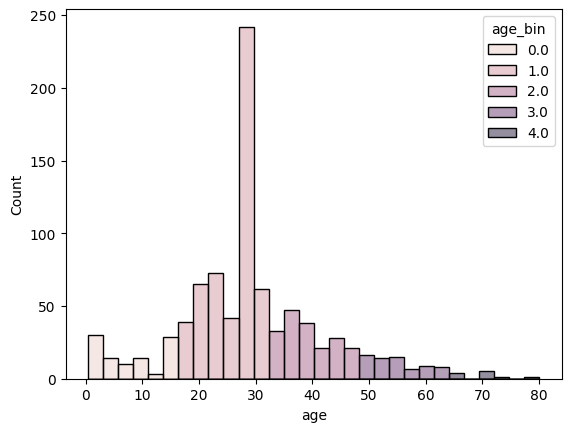

In [9]:
sns.histplot(df,x='age', hue=df['age_bin'])

In [ ]:
# pandas method for manual binning
df['age_bin2'] =pd.cut(df['age'], bins=3, labels=[1,2,3])



<Axes: xlabel='age', ylabel='Count'>

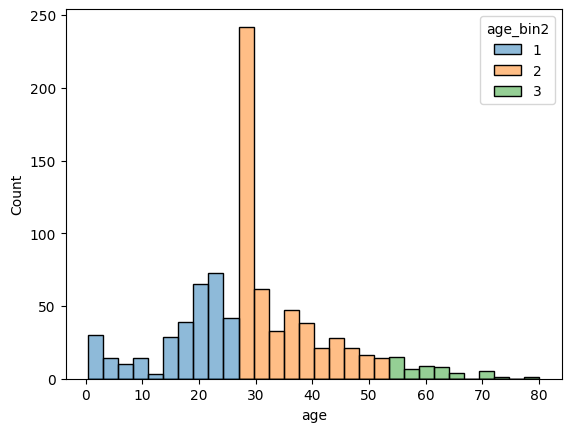

In [11]:
sns.histplot(df,x='age', hue=df['age_bin2'])

<Axes: xlabel='age', ylabel='Count'>

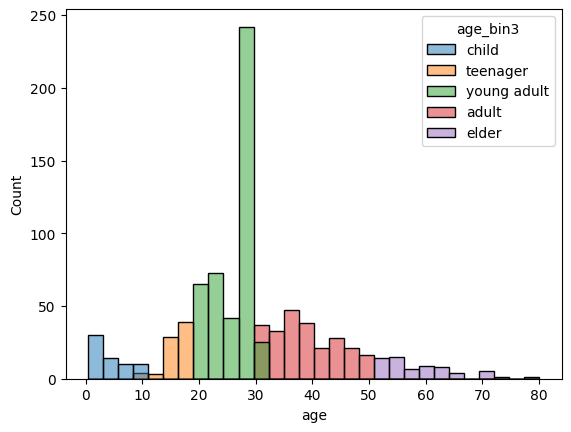

In [13]:
# difine the bins 
age_bins = [0, 10, 18, 30, 50, 80]
labels = ['child', 'teenager', 'young adult', 'adult', 'elder']
df['age_bin3'] = pd.cut(df['age'], bins=age_bins, labels=labels)
sns.histplot(df,x='age', hue=df['age_bin3'])